# UMAP Clustering of Discriminative Neurons

Clustering and visualizing discriminative **neurons** (not samples) using UMAP dimensionality reduction.

Each point represents one neuron, characterized by its activation pattern across 3,000 text samples.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import umap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

In [34]:
# Load labels for samples
labels = np.load('../results/activations/labels.npy')

# Load discriminative neurons from all layers
neuron_activations = []  # Each row will be a neuron's activation across all samples
neuron_info = []

for layer in range(1, 13):
    # Load neuron stats
    stats = pd.read_csv(f'../results/activations/layer_{layer}_neuron_stats.csv')
    
    # Filter discriminative neurons
    disc_neurons = stats[stats['discriminative'] == True]
    
    if len(disc_neurons) > 0:
        # Load activations (shape: samples x neurons)
        activations = np.load(f'../results/activations/layer_{layer}_activations.npy')
        
        # Extract discriminative neuron activations
        for idx in disc_neurons['neuron_idx']:
            # Take the neuron's activation pattern across all samples
            neuron_activations.append(activations[:, idx])
            
            neuron_row = disc_neurons[disc_neurons['neuron_idx'] == idx].iloc[0]
            neuron_info.append({
                'layer': layer,
                'neuron_idx': idx,
                'auc': neuron_row['auc'],
                'direction': neuron_row['direction'],
                'auc_deviation': abs(neuron_row['auc'] - 0.5)
            })

# Stack into matrix: (neurons x samples)
# Each ROW is a neuron, each COLUMN is a sample
X_neurons = np.array(neuron_activations)
neuron_df = pd.DataFrame(neuron_info)

print(f"Shape: {X_neurons.shape}")
print(f"Total discriminative neurons: {X_neurons.shape[0]}")
print(f"Samples per neuron: {X_neurons.shape[1]}")
print(f"\nNeurons per layer:")
print(neuron_df['layer'].value_counts().sort_index())
print(f"\nDirection distribution:")
print(neuron_df['direction'].value_counts())


Shape: (1350, 10000)
Total discriminative neurons: 1350
Samples per neuron: 10000

Neurons per layer:
layer
1     128
2     111
3     116
4      83
5      84
6      95
7      84
8      45
9      89
10    164
11    181
12    170
Name: count, dtype: int64

Direction distribution:
direction
AI-preferring       688
Human-preferring    662
Name: count, dtype: int64


## UMAP Dimensionality Reduction on Neurons

In [35]:
# Apply UMAP to neurons (1350 points)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='correlation',
    random_state=42
)

# Each point in embedding represents ONE NEURON
embedding = reducer.fit_transform(X_neurons)
print(f"UMAP embedding shape: {embedding.shape}")
print(f"Each of the {embedding.shape[0]} points represents one neuron")

c:\Users\Pawel\anaconda3\envs\human-vs-ai\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (1350, 2)
Each of the 1350 points represents one neuron


## Initial UMAP Visualization (Before Clustering)

Visualize neuron organization by layer depth and preference direction.


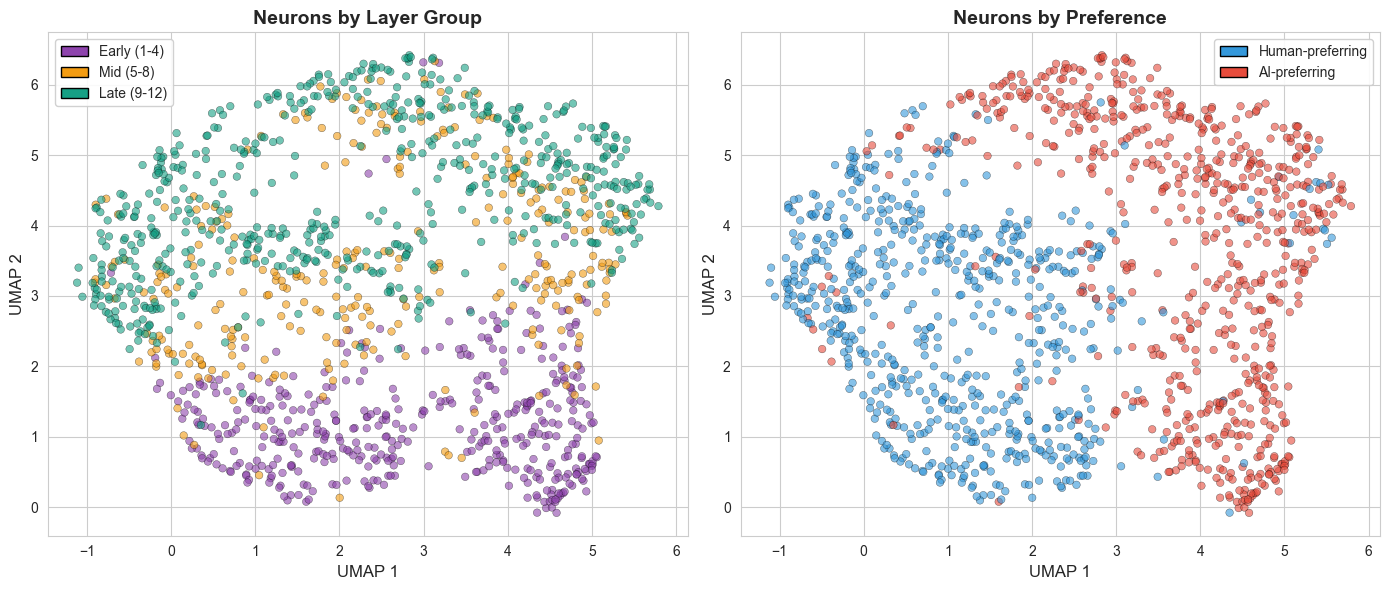

✓ Initial UMAP visualization saved to results/figures/neuron_umap_layers_preference.png


In [36]:
# Create layer groups for visualization
def layer_to_group(layer):
    if layer <= 4:
        return 0  # Early layers (1-4)
    elif layer <= 8:
        return 1  # Mid layers (5-8)
    else:
        return 2  # Late layers (9-12)

neuron_df['layer_group'] = neuron_df['layer'].apply(layer_to_group)

# Create 2-panel figure: Layer groups and Preference
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Color by layer groups (Early, Mid, Late)
layer_colors_map = {0: '#8e44ad', 1: '#f39c12', 2: '#16a085'}  # Purple, Orange, Teal
layer_group_colors = [layer_colors_map[g] for g in neuron_df['layer_group']]

axes[0].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=layer_group_colors,
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidths=0.3
)
axes[0].set_title('Neurons by Layer Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)

layer_legend = [
    Patch(facecolor='#8e44ad', edgecolor='black', label='Early (1-4)'),
    Patch(facecolor='#f39c12', edgecolor='black', label='Mid (5-8)'),
    Patch(facecolor='#16a085', edgecolor='black', label='Late (9-12)')
]
axes[0].legend(handles=layer_legend, loc='best', framealpha=0.9)

# Panel 2: Color by direction (AI vs Human preference)
direction_colors_map = {'Human-preferring': '#3498db', 'AI-preferring': '#e74c3c'}  # Blue, Red
direction_colors = [direction_colors_map[d] for d in neuron_df['direction']]

axes[1].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=direction_colors,
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidths=0.3
)
axes[1].set_title('Neurons by Preference', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)

pref_legend = [
    Patch(facecolor='#3498db', edgecolor='black', label='Human-preferring'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='AI-preferring')
]
axes[1].legend(handles=pref_legend, loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig('../results/figures/neuron_umap_layers_preference.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Initial UMAP visualization saved to results/figures/neuron_umap_layers_preference.png")


## Hierarchical Clustering with Ward Linkage

Performing hierarchical clustering with Ward linkage...


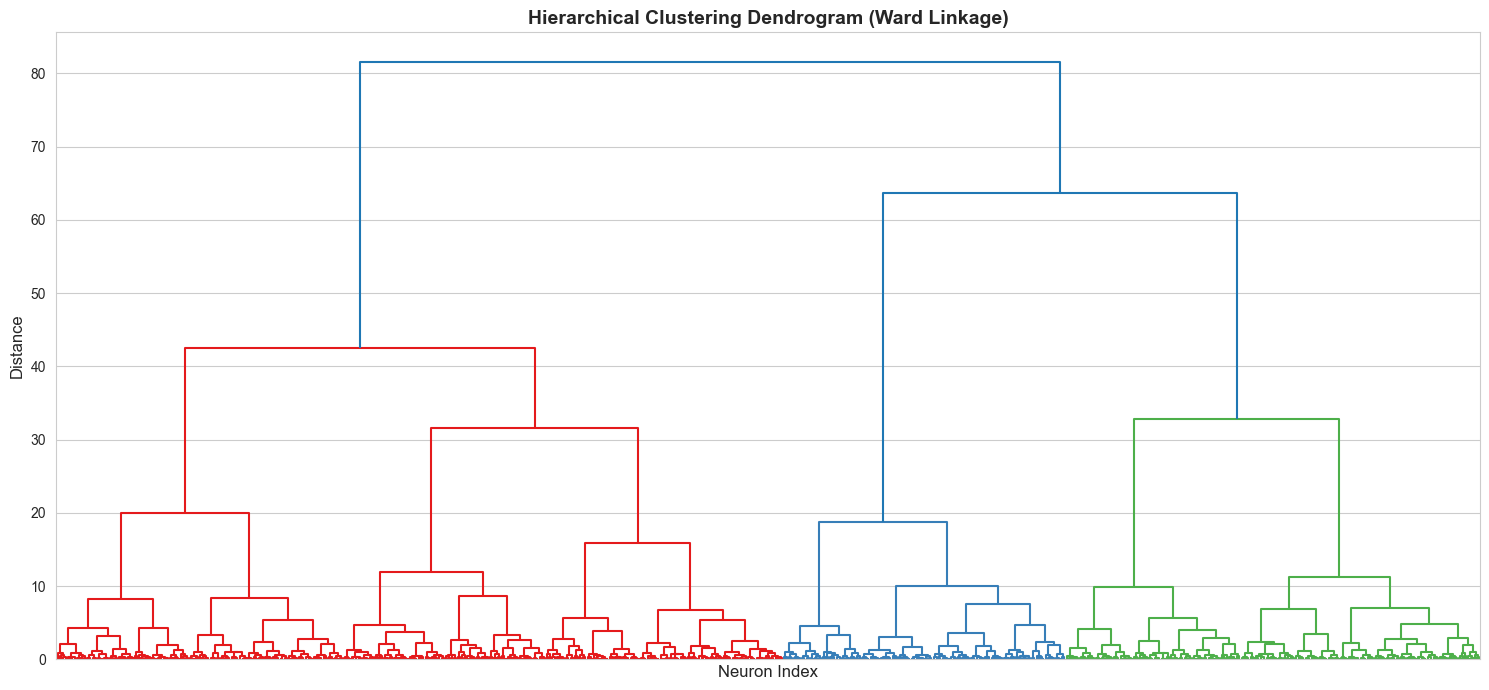

In [37]:
# Perform hierarchical clustering on UMAP embedding
print("Performing hierarchical clustering with Ward linkage...")
print("=" * 60)

# Compute linkage matrix
Z = linkage(embedding, method='ward')

# Visualize dendrogram
plt.figure(figsize=(15, 7))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Neuron Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)

## Final Clustering with Optimal K

Evaluating optimal number of clusters...
K=2: Silhouette Score = 0.3716
K=3: Silhouette Score = 0.4058
K=4: Silhouette Score = 0.3939
K=5: Silhouette Score = 0.3923
------------------------------------------------------------
✓ Optimal K: 3 (Silhouette Score: 0.4058)


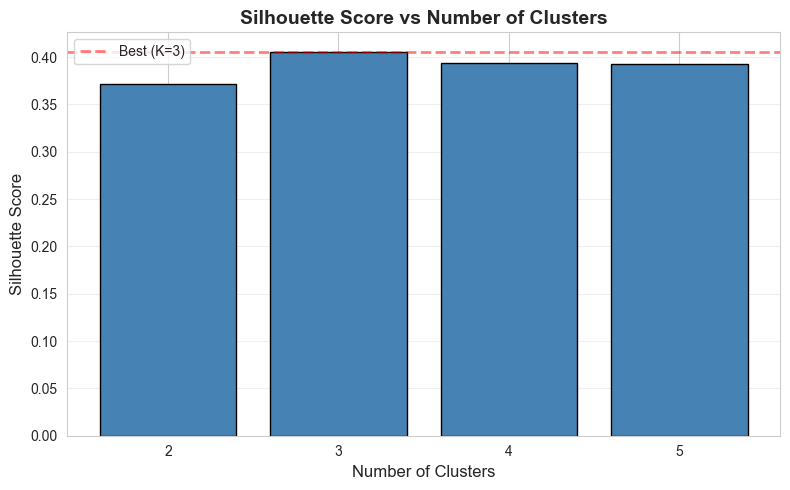


✓ Silhouette scores saved to results/figures/neuron_silhouette_scores.png


In [38]:
# Test different numbers of clusters (3, 4, 5) and evaluate with silhouette score
print("Evaluating optimal number of clusters...")
print("=" * 60)

k_range = range(2, 6)
silhouette_scores = {}

for k in k_range:
    # Cut dendrogram to get k clusters
    clusters = fcluster(Z, t=k, criterion='maxclust')
    
    # Calculate silhouette score
    score = silhouette_score(embedding, clusters)
    silhouette_scores[k] = score
    
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Find optimal K
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
best_silhouette = silhouette_scores[optimal_k]

print("-" * 60)
print(f"✓ Optimal K: {optimal_k} (Silhouette Score: {best_silhouette:.4f})")

# Visualize silhouette scores
plt.figure(figsize=(8, 5))
plt.bar(k_range, [silhouette_scores[k] for k in k_range], color='steelblue', edgecolor='black')
plt.axhline(best_silhouette, color='red', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'Best (K={optimal_k})')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/neuron_silhouette_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Silhouette scores saved to results/figures/neuron_silhouette_scores.png")
print("=" * 60)

## Dendrogram with Optimal Cut


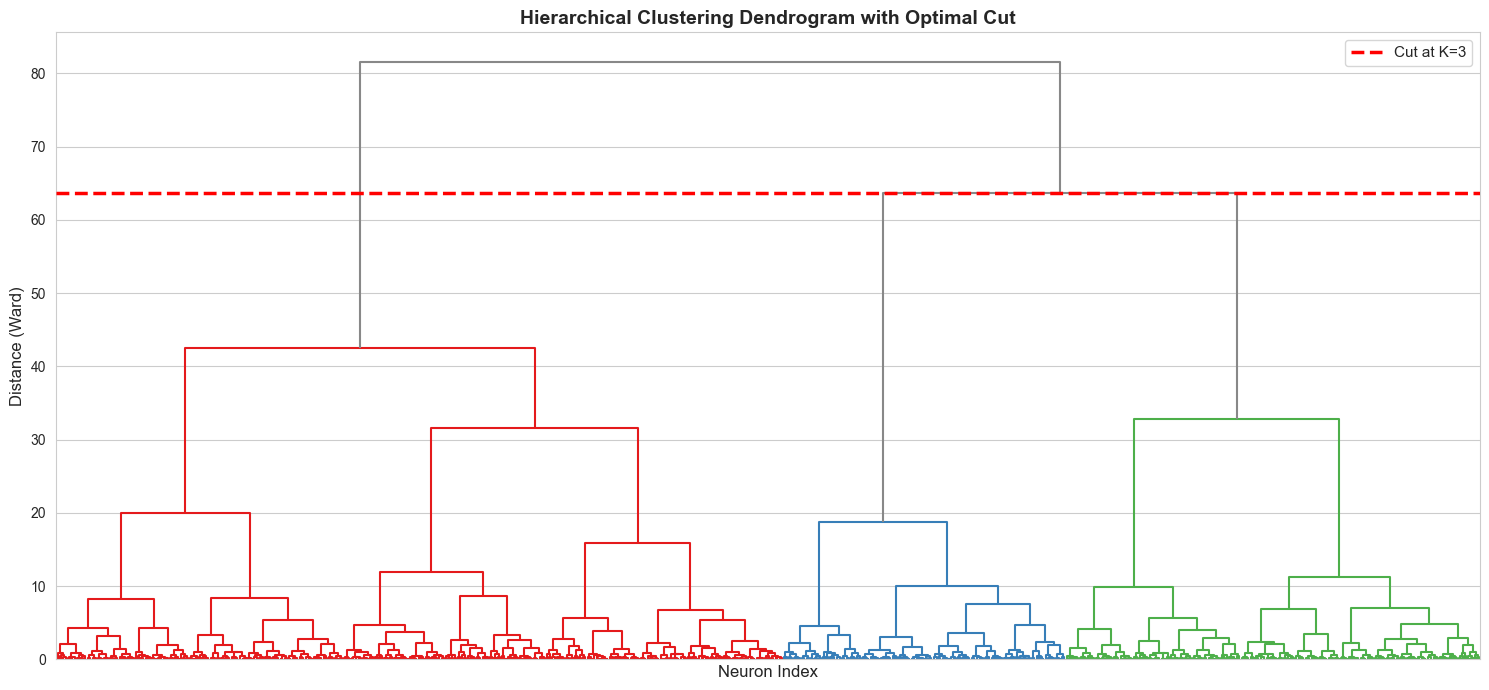

✓ Dendrogram with K=3 cut saved to results/figures/neuron_dendrogram_cut.png


In [39]:
# Visualize dendrogram with cut line at optimal K and colored clusters
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette
import matplotlib.pyplot as plt

# Use the same vibrant color palette as UMAP clusters
cluster_colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'][:optimal_k]
set_link_color_palette(cluster_colors_palette)

plt.figure(figsize=(15, 7))

# Calculate the correct distance threshold for optimal_k clusters
# In linkage matrix Z, row i represents the merge at step i
# Z has shape (n-1, 4), where n is number of points
# Z[-1, 2] is the final merge distance (top of dendrogram)
# Z[-2, 2] is the second-to-last merge distance (creates 2 clusters)
# Z[-(k-1), 2] is the merge that creates k clusters
# For k=3, we want Z[-2, 2] - the height just before going from 3->2 clusters
cut_height = Z[-(optimal_k-1), 2]

# Draw dendrogram with colors below threshold
dendro = dendrogram(Z, no_labels=True, color_threshold=cut_height, above_threshold_color='#888888')

# Add cut line
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2.5, label=f'Cut at K={optimal_k}', zorder=10)

plt.title('Hierarchical Clustering Dendrogram with Optimal Cut', fontsize=14, fontweight='bold')
plt.xlabel('Neuron Index', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('../results/figures/neuron_dendrogram_cut.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Dendrogram with K={optimal_k} cut saved to results/figures/neuron_dendrogram_cut.png")

## Final Cluster Assignment

In [40]:
# Cut dendrogram at optimal K to get final cluster assignments
n_clusters = optimal_k
neuron_clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

# Adjust to 0-indexed
neuron_clusters = neuron_clusters - 1

# Add cluster info to neuron_df
neuron_df['cluster'] = neuron_clusters

print(f"Final hierarchical clustering with K={n_clusters}")
print("=" * 60)
print(f"Neuron cluster distribution:")
for i in range(n_clusters):
    n_neurons = np.sum(neuron_clusters == i)
    print(f"  Cluster {i}: {n_neurons} neurons")
print("=" * 60)


Final hierarchical clustering with K=3
Neuron cluster distribution:
  Cluster 0: 689 neurons
  Cluster 1: 268 neurons
  Cluster 2: 393 neurons


## UMAP with Cluster Assignment

Visualize the identified clusters in UMAP space.

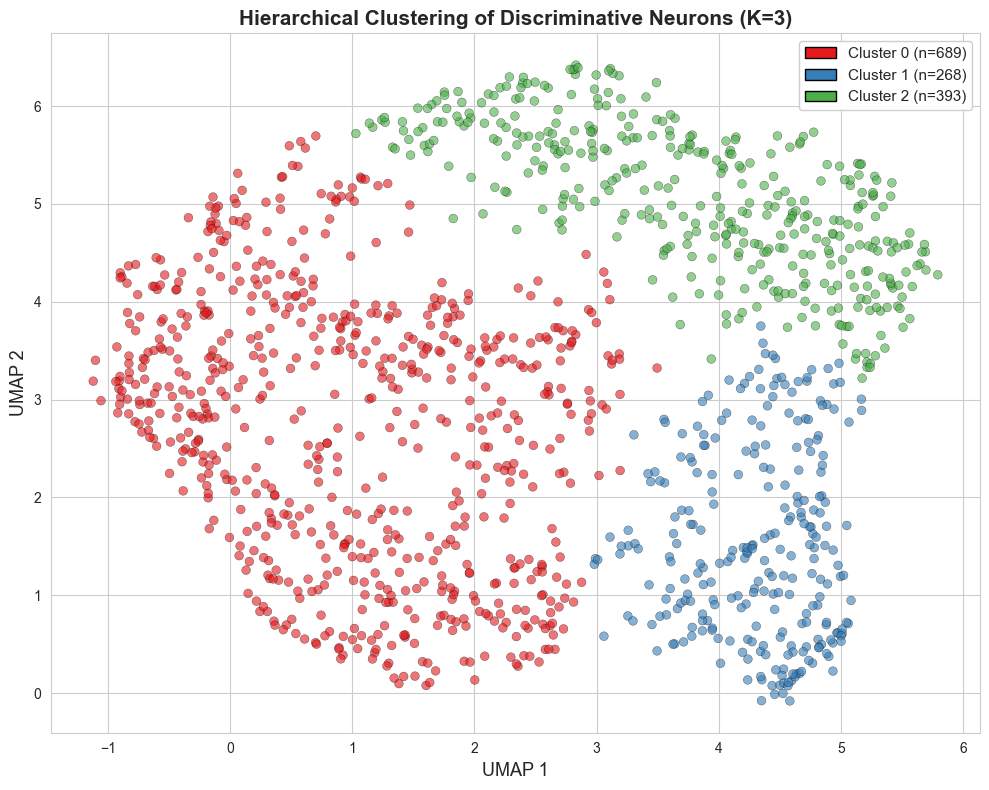

✓ Cluster visualization saved to results/figures/neuron_umap_clusters.png


In [41]:
# Create single-panel figure showing cluster assignments
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 8))

# Define vibrant colors for clusters
cluster_colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'][:n_clusters]
cluster_colors = [cluster_colors_palette[c] for c in neuron_clusters]

ax.scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=cluster_colors,
    alpha=0.6,
    s=40,
    edgecolors='black',
    linewidths=0.3
)
ax.set_title(f'Hierarchical Clustering of Discriminative Neurons (K={n_clusters})', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=13)
ax.set_ylabel('UMAP 2', fontsize=13)

# Add legend for clusters
legend_elements = [Patch(facecolor=cluster_colors_palette[i], edgecolor='black', 
                         label=f'Cluster {i} (n={np.sum(neuron_clusters == i)})')
                   for i in range(n_clusters)]
ax.legend(handles=legend_elements, loc='best', framealpha=0.95, fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/neuron_umap_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster visualization saved to results/figures/neuron_umap_clusters.png")

## Cluster Analysis

In [42]:
# Analyze cluster properties
print("=" * 80)
print("NEURON CLUSTER ANALYSIS")
print("=" * 80)

for cluster_id in range(n_clusters):
    cluster_neurons = neuron_df[neuron_df['cluster'] == cluster_id]
    
    print(f"\nCluster {cluster_id}: {len(cluster_neurons)} neurons")
    print("-" * 80)
    
    # Layer distribution
    print("  Layer distribution:")
    layer_counts = cluster_neurons['layer'].value_counts().sort_index()
    for layer, count in layer_counts.items():
        pct = count / len(cluster_neurons) * 100
        print(f"    Layer {layer:2d}: {count:3d} neurons ({pct:5.1f}%)")
    
    # Direction preference
    print("\n  Direction preference:")
    direction_counts = cluster_neurons['direction'].value_counts()
    for direction, count in direction_counts.items():
        pct = count / len(cluster_neurons) * 100
        print(f"    {direction}: {count:3d} neurons ({pct:5.1f}%)")
    
    # AUC statistics
    print("\n  AUC statistics:")
    print(f"    Mean AUC: {cluster_neurons['auc'].mean():.4f}")
    print(f"    Std AUC:  {cluster_neurons['auc'].std():.4f}")
    print(f"    Mean AUC deviation: {cluster_neurons['auc_deviation'].mean():.4f}")

print("\n" + "=" * 80)


NEURON CLUSTER ANALYSIS

Cluster 0: 689 neurons
--------------------------------------------------------------------------------
  Layer distribution:
    Layer  1:  62 neurons (  9.0%)
    Layer  2:  54 neurons (  7.8%)
    Layer  3:  58 neurons (  8.4%)
    Layer  4:  45 neurons (  6.5%)
    Layer  5:  45 neurons (  6.5%)
    Layer  6:  52 neurons (  7.5%)
    Layer  7:  40 neurons (  5.8%)
    Layer  8:  19 neurons (  2.8%)
    Layer  9:  48 neurons (  7.0%)
    Layer 10:  89 neurons ( 12.9%)
    Layer 11:  91 neurons ( 13.2%)
    Layer 12:  86 neurons ( 12.5%)

  Direction preference:
    Human-preferring: 633 neurons ( 91.9%)
    AI-preferring:  56 neurons (  8.1%)

  AUC statistics:
    Mean AUC: 0.2951
    Std AUC:  0.1352
    Mean AUC deviation: 0.2428

Cluster 1: 268 neurons
--------------------------------------------------------------------------------
  Layer distribution:
    Layer  1:  66 neurons ( 24.6%)
    Layer  2:  57 neurons ( 21.3%)
    Layer  3:  57 neurons ( 21.3

## Summary Statistics

In [43]:
# Print final summary
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\nTotal discriminative neurons: {X_neurons.shape[0]}")
print(f"Samples per neuron: {X_neurons.shape[1]}")
print(f"Optimal K (based on Silhouette Score): {n_clusters}")
print(f"Best Silhouette Score: {best_silhouette:.4f}")
print(f"\nOverall direction distribution:")
print(neuron_df['direction'].value_counts())
print(f"\nOverall layer distribution:")
print(neuron_df['layer'].value_counts().sort_index())
print("\n" + "=" * 80)

FINAL SUMMARY

Total discriminative neurons: 1350
Samples per neuron: 10000
Optimal K (based on Silhouette Score): 3
Best Silhouette Score: 0.4058

Overall direction distribution:
direction
AI-preferring       688
Human-preferring    662
Name: count, dtype: int64

Overall layer distribution:
layer
1     128
2     111
3     116
4      83
5      84
6      95
7      84
8      45
9      89
10    164
11    181
12    170
Name: count, dtype: int64

